Hugo Tanaka
CSCI 611
Professor Bo Shen
2026 March 20

# Style Transfer with Deep Neural Networks


In this notebook, we’ll *recreate* a style transfer method that is outlined in the paper, [Image Style Transfer Using Convolutional Neural Networks, by Gatys](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/Gatys_Image_Style_Transfer_CVPR_2016_paper.pdf) in PyTorch.

In this notebook, we'll use a pre-trained VGG19 Net to extract content or style features from a passed in image. We'll then formalize the idea of content and style _losses_ and use those to iteratively update our target image until we get a result that we want. You are encouraged to use a style and content image of your own.

In [1]:
# import resources
%matplotlib inline

from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.optim as optim
import requests
from torchvision import transforms, models

## Load in VGG19 (features)

VGG19 is split into two portions:
* `vgg19.features`, which are all the convolutional and pooling layers
* `vgg19.classifier`, which are the three linear, classifier layers at the end

We only need the `features` portion, which we're going to load in and "freeze" the weights of, below.

In [2]:
# get the "features" portion of VGG19 (we will not need the "classifier" portion)
vgg = models.vgg19(pretrained=True).features

# freeze all VGG parameters since we're only optimizing the target image
for param in vgg.parameters():
    param.requires_grad_(False)

/home/kanae/school/chicoSpring2026/CSCI611/Assignment4/as4/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kanae/school/chicoSpring2026/CSCI611/Assignment4/as4/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [3]:
# move the model to GPU, if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vgg.to(device)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

### Load in Content and Style Images

You can load in any images you want! Below, we've provided a helper function for loading in any type and size of image. The `load_image` function also converts images to normalized Tensors.

Additionally, it will be easier to have smaller images and to squish the content and style images so that they are of the same size.

In [4]:
def load_image(img_path, max_size=400, shape=None):
    ''' Load in and transform an image, making sure the image
       is <= 400 pixels in the x-y dims.'''
    if "http" in img_path:
        response = requests.get(img_path)
        image = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        image = Image.open(img_path).convert('RGB')
    
    # large images will slow down processing
    if max(image.size) > max_size:
        size = max_size
    else:
        size = max(image.size)

    if shape is not None:
        size = shape
        
    in_transform = transforms.Compose([
                        transforms.Resize(size),
                        transforms.ToTensor(),
                        transforms.Normalize((0.485, 0.456, 0.406), 
                                             (0.229, 0.224, 0.225))])

    # discard the transparent, alpha channel (that's the :3) and add the batch dimension
    image = in_transform(image)[:3,:,:].unsqueeze(0)
    
    return image

Next, I'm loading in images by file name and forcing the style image to be the same size as the content image.

**TODO**: use your content vs style images.

Used photo of SF for content and Van Goth's drawing for style.

In [5]:
# load in content and style image
content = load_image('SF.jpg').to(device)
# Resize style to match content, makes code easier
style = load_image('goth.jpg', shape=content.shape[-2:]).to(device)

# helper function for un-normalizing an image 
# and converting it from a Tensor image to a NumPy image for display
def im_convert(tensor):
    """ Display a tensor as an image. """
    
    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1,2,0)
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
    image = image.clip(0, 1)

    return image

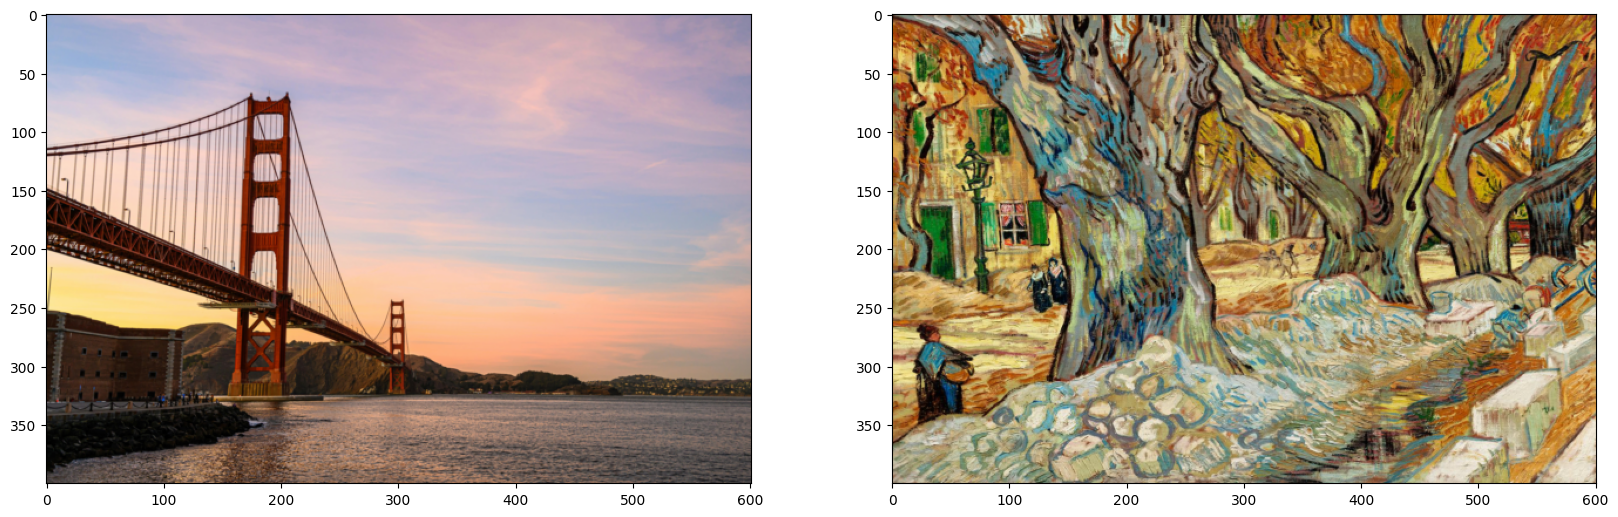

In [6]:
# display the images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
# content and style ims side-by-side
ax1.imshow(im_convert(content))
ax2.imshow(im_convert(style))

---
## VGG19 Layers

To get the content and style representations of an image, we have to pass an image forward through the VGG19 network until we get to the desired layer(s) and then get the output from that layer.

In [7]:
# print out VGG19 structure so you can see the names of various layers
print(vgg)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

## Content and Style Features

#### **TODO**: complete the mapping of layer names to the names found in the paper for the _content representation_ and the _style representation_.

The first layer (0) to `conv1_1` has been done for you, below.

In [8]:
def get_features(image, model, layers=None):
    """ Run an image forward through a model and get the features for 
        a set of layers. Default layers are for VGGNet matching Gatys et al (2016)
    """
    
    ## TODO: Complete mapping layer names of PyTorch's VGGNet to names from the paper
    ## Need the layers for the content and style representations of an image
    if layers is None:
        layers = {
            '0': 'conv1_1',
            '5': 'conv2_1',
            '10': 'conv3_1',
            '19': 'conv4_1',
            '21': 'conv4_2',
            '28': 'conv5_1'
        }
        
        
    ## -- do not need to change the code below this line -- ##
    features = {}
    x = image
    # model._modules is a dictionary holding each module in the model
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
            
    return features

---
## Gram Matrix 

The output of every convolutional layer is a Tensor with dimensions associated with the `batch_size`, a depth, `d` and some height and width (`h`, `w`). The Gram matrix of a convolutional layer can be calculated as follows:
* Get the depth, height, and width of a tensor using `batch_size, d, h, w = tensor.size()`
* Reshape that tensor so that the spatial dimensions are flattened
* Calculate the gram matrix by multiplying the reshaped tensor by it's transpose 

*Note: You can multiply two matrices using `torch.mm(matrix1, matrix2)`.*

#### TODO: Complete the `gram_matrix` function.

In [9]:
def gram_matrix(tensor):
    """ Calculate the Gram Matrix of a given tensor 
        Gram Matrix: https://en.wikipedia.org/wiki/Gramian_matrix
    """
    
    ## get the batch_size, depth, height, and width of the Tensor
    ## reshape it, so we're multiplying the features for each channel
    ## calculate the gram matrix

    # https://docs.pytorch.org/docs/stable/generated/torch.Tensor.size.html
    batch_size, depth, height, width = tensor.size()

    # https://docs.pytorch.org/docs/stable/generated/torch.Tensor.view.html#torch-tensor-view
    tensor = tensor.view((batch_size * depth), (height*width))

    gram = torch.mm(tensor, tensor.t())
    
    return gram 

## Putting it all Together

Now that we've written functions for extracting features and computing the gram matrix of a given convolutional layer; let's put all these pieces together! We'll extract our features from our images and calculate the gram matrices for each layer in our style representation.

In [10]:
# get content and style features only once before forming the target image
content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

# calculate the gram matrices for each layer of our style representation
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

# create a third "target" image and prep it for change
# it is a good idea to start off with the target as a copy of our *content* image
# then iteratively change its style
target = content.clone().requires_grad_(True).to(device)

---
## Loss and Weights

#### Individual Layer Style Weights

Below, you are given the option to weight the style representation at each relevant layer. It's suggested that you use a range between 0-1 to weight these layers. By weighting earlier layers (`conv1_1` and `conv2_1`) more, you can expect to get _larger_ style artifacts in your resulting, target image. Should you choose to weight later layers, you'll get more emphasis on smaller features. This is because each layer is a different size and together they create a multi-scale style representation!

#### Content and Style Weight

Just like in the paper, we define an alpha (`content_weight`) and a beta (`style_weight`). This ratio will affect how _stylized_ your final image is. It's recommended that you leave the content_weight = 1 and set the style_weight to achieve the ratio you want.

In [11]:
# weights for each style layer 
# weighting earlier layers more will result in *larger* style artifacts
# notice we are excluding `conv4_2` our content representation
style_weights = {'conv1_1': 1.,
                 'conv2_1': 0.8,
                 'conv3_1': 0.5,
                 'conv4_1': 0.3,
                 'conv5_1': 0.1}

# you may choose to leave these as is
content_weight = 1  # alpha
style_weight = 1e6  # beta

## Updating the Target & Calculating Losses

You'll decide on a number of steps for which to update your image, this is similar to the training loop that you've seen before, only we are changing our _target_ image and nothing else about VGG19 or any other image. Therefore, the number of steps is really up to you to set! **I recommend using at least 2000 steps for good results.** But, you may want to start out with fewer steps if you are just testing out different weight values or experimenting with different images.

Inside the iteration loop, you'll calculate the content and style losses and update your target image, accordingly.

#### Content Loss

The content loss will be the mean squared difference between the target and content features at layer `conv4_2`. This can be calculated as follows: 
```
content_loss = torch.mean((target_features['conv4_2'] - content_features['conv4_2'])**2)
```

#### Style Loss

The style loss is calculated in a similar way, only you have to iterate through a number of layers, specified by name in our dictionary `style_weights`. 
> You'll calculate the gram matrix for the target image, `target_gram` and style image `style_gram` at each of these layers and compare those gram matrices, calculating the `layer_style_loss`. 
> Later, you'll see that this value is normalized by the size of the layer.

#### Total Loss

Finally, you'll create the total loss by adding up the style and content losses and weighting them with your specified alpha and beta!

Intermittently, we'll print out this loss; don't be alarmed if the loss is very large. It takes some time for an image's style to change and you should focus on the appearance of your target image rather than any loss value. Still, you should see that this loss decreases over some number of iterations.

#### TODO: Define content, style, and total losses.

Stylizing:   0%|          | 0/2000 [00:00<?, ?it/s]

Style loss raw: 748.1528930664062
Step 10/2000 | Total: 620272768.0000 | Content: 1.5478 | Style: 620.2728
Step 20/2000 | Total: 495173920.0000 | Content: 3.1062 | Style: 495.1739
Step 30/2000 | Total: 395239264.0000 | Content: 4.0781 | Style: 395.2393
Step 40/2000 | Total: 315740192.0000 | Content: 4.8489 | Style: 315.7402
Step 50/2000 | Total: 255178672.0000 | Content: 5.5845 | Style: 255.1787
Step 60/2000 | Total: 210091056.0000 | Content: 6.1803 | Style: 210.0910
Step 70/2000 | Total: 176433616.0000 | Content: 6.6652 | Style: 176.4336
Step 80/2000 | Total: 150986000.0000 | Content: 7.0816 | Style: 150.9860
Step 90/2000 | Total: 131336888.0000 | Content: 7.4289 | Style: 131.3369
Step 100/2000 | Total: 115834576.0000 | Content: 7.7177 | Style: 115.8346
Step 110/2000 | Total: 103325240.0000 | Content: 7.9686 | Style: 103.3252
Step 120/2000 | Total: 93014912.0000 | Content: 8.1921 | Style: 93.0149
Step 130/2000 | Total: 84378528.0000 | Content: 8.3897 | Style: 84.3785
Step 140/2000 | T

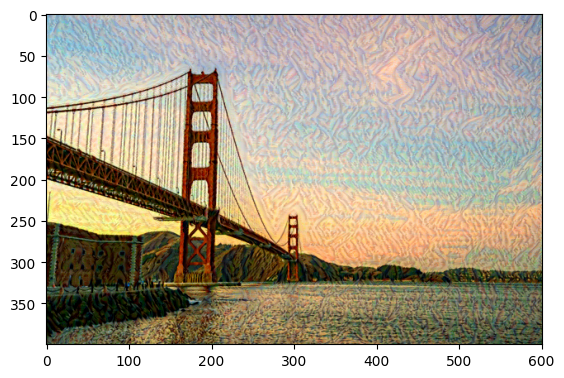

Step 410/2000 | Total: 19853408.0000 | Content: 10.7392 | Style: 19.8534
Step 420/2000 | Total: 19299870.0000 | Content: 10.7807 | Style: 19.2999
Step 430/2000 | Total: 18778412.0000 | Content: 10.8206 | Style: 18.7784
Step 440/2000 | Total: 18286578.0000 | Content: 10.8594 | Style: 18.2866
Step 450/2000 | Total: 17821422.0000 | Content: 10.8970 | Style: 17.8214
Step 460/2000 | Total: 17380790.0000 | Content: 10.9334 | Style: 17.3808
Step 470/2000 | Total: 16963098.0000 | Content: 10.9686 | Style: 16.9631
Step 480/2000 | Total: 16566478.0000 | Content: 11.0028 | Style: 16.5665
Step 490/2000 | Total: 16189258.0000 | Content: 11.0371 | Style: 16.1892
Step 500/2000 | Total: 15830082.0000 | Content: 11.0705 | Style: 15.8301
Step 510/2000 | Total: 15487589.0000 | Content: 11.1029 | Style: 15.4876
Step 520/2000 | Total: 15160728.0000 | Content: 11.1344 | Style: 15.1607
Step 530/2000 | Total: 14848329.0000 | Content: 11.1647 | Style: 14.8483
Step 540/2000 | Total: 14549401.0000 | Content: 11.

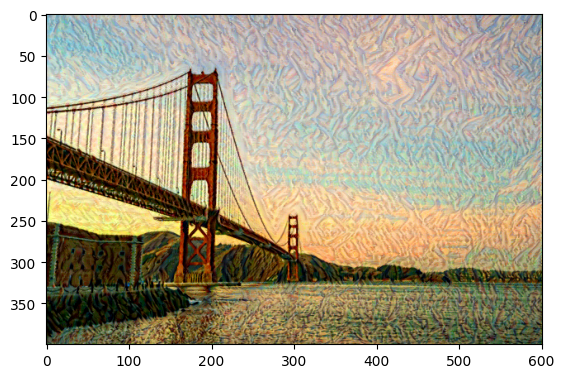

Step 810/2000 | Total: 9490484.0000 | Content: 11.7903 | Style: 9.4905
Step 820/2000 | Total: 9369335.0000 | Content: 11.8076 | Style: 9.3693
Step 830/2000 | Total: 9251037.0000 | Content: 11.8249 | Style: 9.2510
Step 840/2000 | Total: 9135534.0000 | Content: 11.8420 | Style: 9.1355
Step 850/2000 | Total: 9022661.0000 | Content: 11.8588 | Style: 9.0226
Step 860/2000 | Total: 8912313.0000 | Content: 11.8755 | Style: 8.9123
Step 870/2000 | Total: 8804379.0000 | Content: 11.8918 | Style: 8.8044
Step 880/2000 | Total: 8698796.0000 | Content: 11.9078 | Style: 8.6988
Step 890/2000 | Total: 8595495.0000 | Content: 11.9235 | Style: 8.5955
Step 900/2000 | Total: 8494342.0000 | Content: 11.9388 | Style: 8.4943
Step 910/2000 | Total: 8395341.0000 | Content: 11.9537 | Style: 8.3953
Step 920/2000 | Total: 8298387.0000 | Content: 11.9687 | Style: 8.2984
Step 930/2000 | Total: 8203373.5000 | Content: 11.9836 | Style: 8.2034
Step 940/2000 | Total: 8110192.0000 | Content: 11.9981 | Style: 8.1102
Step 9

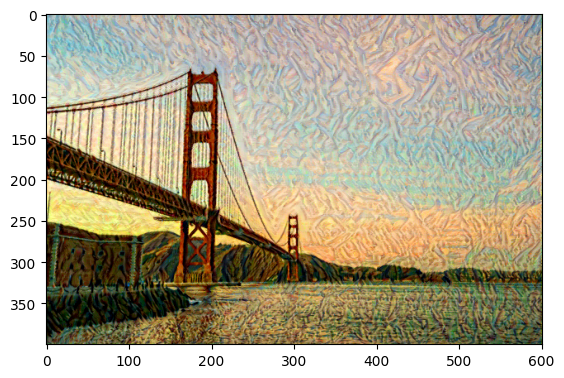

Step 1210/2000 | Total: 6136703.5000 | Content: 12.3361 | Style: 6.1367
Step 1220/2000 | Total: 6078813.0000 | Content: 12.3470 | Style: 6.0788
Step 1230/2000 | Total: 6021747.5000 | Content: 12.3577 | Style: 6.0217
Step 1240/2000 | Total: 5965486.0000 | Content: 12.3684 | Style: 5.9655
Step 1250/2000 | Total: 5910003.5000 | Content: 12.3788 | Style: 5.9100
Step 1260/2000 | Total: 5855279.5000 | Content: 12.3892 | Style: 5.8553
Step 1270/2000 | Total: 5801310.0000 | Content: 12.3993 | Style: 5.8013
Step 1280/2000 | Total: 5748044.5000 | Content: 12.4096 | Style: 5.7480
Step 1290/2000 | Total: 5695476.0000 | Content: 12.4197 | Style: 5.6955
Step 1300/2000 | Total: 5643600.5000 | Content: 12.4297 | Style: 5.6436
Step 1310/2000 | Total: 5592427.5000 | Content: 12.4397 | Style: 5.5924
Step 1320/2000 | Total: 5541925.0000 | Content: 12.4493 | Style: 5.5419
Step 1330/2000 | Total: 5492076.0000 | Content: 12.4591 | Style: 5.4921
Step 1340/2000 | Total: 5442873.0000 | Content: 12.4690 | Style:

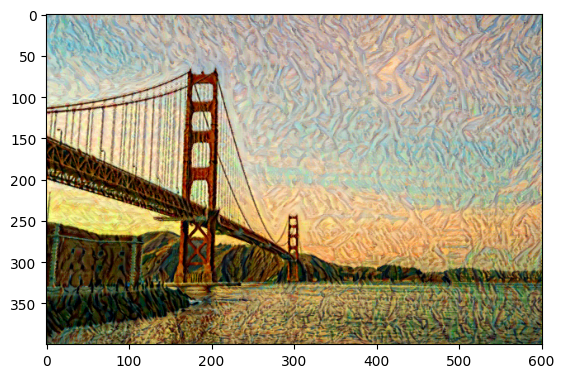

Step 1610/2000 | Total: 4313204.5000 | Content: 12.7094 | Style: 4.3132
Step 1620/2000 | Total: 4277453.0000 | Content: 12.7177 | Style: 4.2774
Step 1630/2000 | Total: 4242056.5000 | Content: 12.7260 | Style: 4.2420
Step 1640/2000 | Total: 4207006.5000 | Content: 12.7343 | Style: 4.2070
Step 1650/2000 | Total: 4172302.0000 | Content: 12.7424 | Style: 4.1723
Step 1660/2000 | Total: 4137945.0000 | Content: 12.7504 | Style: 4.1379
Step 1670/2000 | Total: 4103925.0000 | Content: 12.7583 | Style: 4.1039
Step 1680/2000 | Total: 4070240.2500 | Content: 12.7660 | Style: 4.0702
Step 1690/2000 | Total: 4036878.0000 | Content: 12.7735 | Style: 4.0369
Step 1700/2000 | Total: 4003843.2500 | Content: 12.7810 | Style: 4.0038
Step 1710/2000 | Total: 3971132.7500 | Content: 12.7884 | Style: 3.9711
Step 1720/2000 | Total: 3938749.7500 | Content: 12.7958 | Style: 3.9387
Step 1730/2000 | Total: 3906676.0000 | Content: 12.8032 | Style: 3.9067
Step 1740/2000 | Total: 3874904.2500 | Content: 12.8108 | Style:

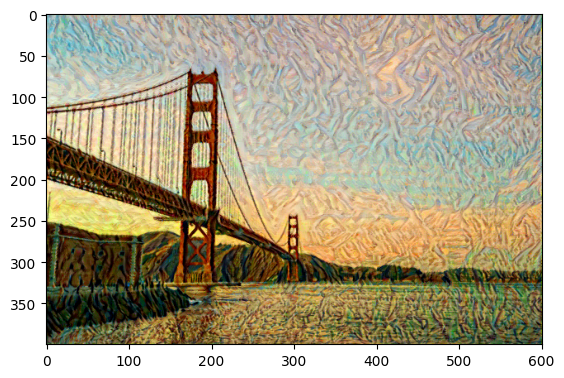

In [12]:
# Needed this to see the progress bar...
from tqdm.notebook import tqdm

# for displaying the target image, intermittently
# show_every = 50
show_every = 400

# iteration hyperparameters
optimizer = optim.Adam([target], lr=0.003)
# steps = 200
steps = 2000  # decide how many iterations to update your image (5000)

# for ii in range(1, steps+1):
for ii in tqdm(range(1, steps+1), desc="Stylizing"):

    ## TODO: get the features from your target image    
    ## Then calculate the content loss
    target_features = get_features(target, vgg)
    content_loss = torch.mean(
        (target_features["conv4_2"] - content_features["conv4_2"]) ** 2
    )
    
    # the style loss
    # initialize the style loss to 0
    style_loss = 0

    # iterate through each style layer and add to the style loss
    for layer in style_weights:
        # get the "target" style representation for the layer
        target_feature = target_features[layer]
        _, depth, height, width = target_feature.shape
        
        ## TODO: Calculate the target gram matrix
        target_gram = gram_matrix(target_feature)
        
        ## TODO:  get the "style" style representation
        style_gram = style_grams[layer]
        ## TODO: Calculate the style loss for one layer, weighted appropriately
        layer_style_loss = style_weights[layer] * torch.mean(
            (target_gram - style_gram) ** 2
        )
        
        # add to the style loss
        style_loss += layer_style_loss / (depth * height * width)
        
        
    ## TODO:  calculate the *total* loss
    total_loss = content_weight * content_loss + style_weight * style_loss
    
    ## -- do not need to change code, below -- ##
    # update your target image
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    # Debug Again
    if ii == 1:
        print("Style loss raw:", style_loss.item())
    Stylizing:   0%
 7/2000 [00:08<39:43,  1.20s/it]

Style loss raw: 748.1528930664062

    # Need to see the progress.... (Debug)
    if ii % 10 == 0:
        print(
            f"Step {ii}/{steps} | "
            f"Total: {total_loss.item():.4f} | "
            f"Content: {content_loss.item():.4f} | "
            f"Style: {style_loss.item():.4f}"
        )
    
    # display intermediate images and print the loss
    if  ii % show_every == 0:
        print('Total loss: ', total_loss.item())
        plt.imshow(im_convert(target))
        plt.show()


# Long story short, this is training the image, NOT the model
# Or chaning the input image ( the output of this)

## Display the Target Image

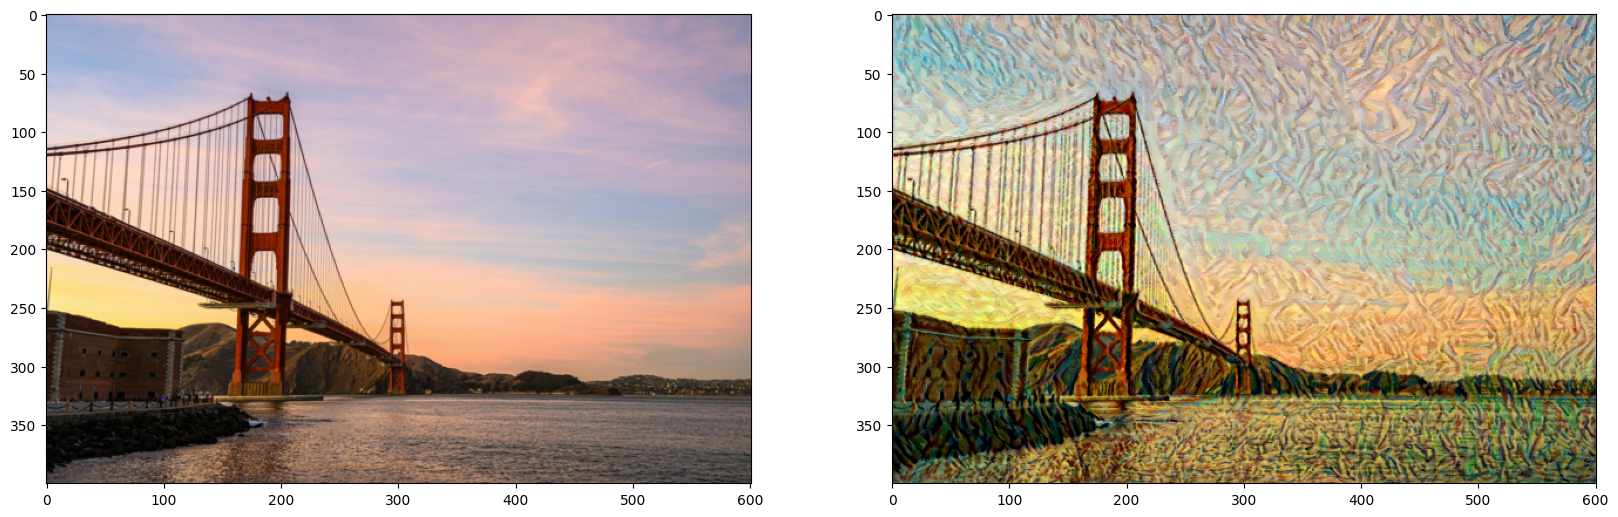

In [13]:
# display content and final, target image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.imshow(im_convert(content))
ax2.imshow(im_convert(target))